# Scenario

You have trained and optimized YOLO models using the Ultralytics framework and now want to deploy them for high-speed inference. You are considering multiple deployment options, including base PyTorch, TensorRT runtime between different model ssizes

Models were trained on a dataset of custom images on fruit ninja mobile game with 2 classes: 'Bomb' and 'fruit'

Time to process one image (Preprocessing, Inference, Postprocessing) and MAP50 are primary metrics for evaluation. 

`VAL_DATA/` contains validation images for testing. 

NOTE: ALL TESTS ARE DONE ON THE SAME HARDWARE SETUP TO ENSURE FAIR COMPARISON.

In [10]:
!nvidia-smi

Tue Jan  6 16:35:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   28C    P8              7W /  320W |     486MiB /  10240MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080


# Initialization

In [14]:
from ultralytics import YOLO
import time
from collections import deque
import os

In [18]:
# Pre loaded model
model_11n = YOLO('MODELS/Tuned_11n.pt')
model_11s = YOLO('MODELS/Tuned_11s.pt')

model_11n.to('cuda')
model_11s.to('cuda')
print("")

One of the fastest ways to run YOLO models is to convert them to TensorRT format. Below are the steps to export and ultralytics YOLO models to TensorRT format.

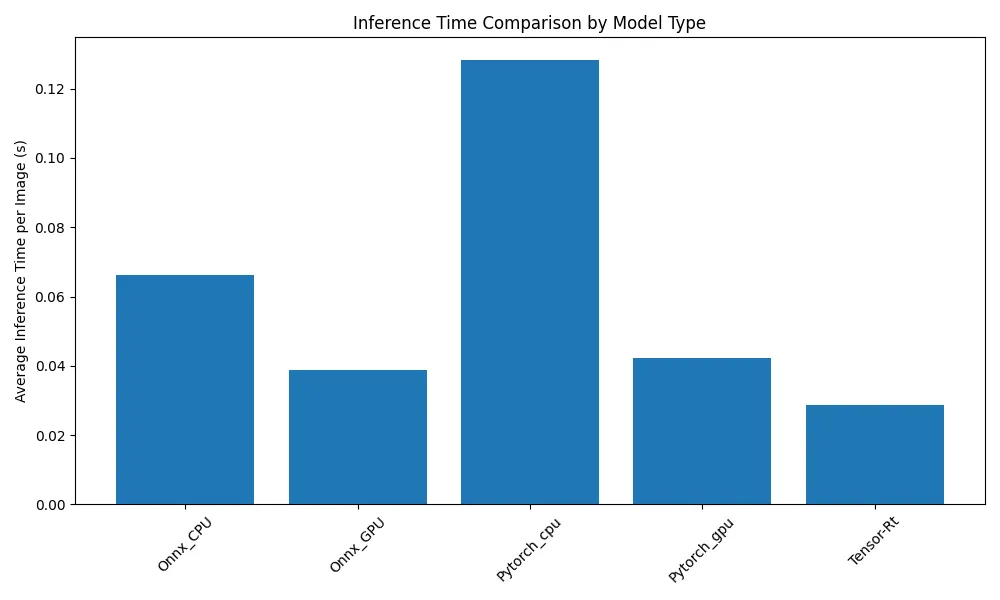

source: https://medium.com/@sundarbalamurugan/comparision-between-tensorrt-pytorch-onnx-runtime-2842bd208d73

In [5]:
# model_11n.export(format='engine', half=True)
# model_11s.export(format='engine', half=True)

# Utils

# 11S VS 11N MODELS BASE PYTORCH

In [20]:
def evaluate_model(model):
    '''

    Returns
    ------------
    - Average_time: str
        Average time to process an image in milliseconds
    - MAP50: float
        Mean Average Precision at IoU 0.5 on the validation dataset
    - F1 Score: float
        F1 Score of the model on the validation dataset (Macro averaged)
    ------------
    '''
    VAL_IMAGES = 'VAL_DATA/images'
    VAL_LABELS = 'VAL_DATA/labels'
    N_IMAGES = len(os.listdir(VAL_IMAGES))

    # Dictionary to map actual labels
    actual_label = {0 : 'fruits', 
                    1 : 'bomb'}
    metrics_class = {
        'fruits' : {
            'TP' : 0,
            'FP' : 0,
            'FN' : 0
        },
        'bomb' : {
            'TP' : 0,
            'FP' : 0,
            'FN' : 0
        },
        'background' : {
            'TP' : 0,
            'FP' : 0,
            'FN' : 0}    
    }

    time_que = deque(maxlen=N_IMAGES)

    for image in os.listdir(VAL_IMAGES):
        st = time.time()
        img_path = os.path.join(VAL_IMAGES, image)
        label_path = os.path.join(VAL_LABELS, image.replace('.jpg', '.txt'))
        results = model.predict(source=img_path, conf=0.25, save=False, save_txt=False)
        et = time.time()
        time_que.append(et - st)
        preds = results[0].boxes
        pred_labels = preds.cls.cpu().numpy() if preds is not None else []
        pred_labels = [int(x) for x in pred_labels]
        with open(label_path, 'r') as f:
            lines = f.readlines()
            true_labels = [int(line.strip().split()[0]) for line in lines]
        for t_label in true_labels:
            if t_label in pred_labels:
                metrics_class[actual_label[t_label]]['TP'] += 1
            else:
                metrics_class[actual_label[t_label]]['FN'] += 1
        for p_label in pred_labels:
            if p_label not in true_labels:
                metrics_class[actual_label[p_label]]['FP'] += 1
    avg_time = (sum(time_que) / N_IMAGES) * 1000  # in milliseconds
    total_AP = 0
    for cls in ['fruits', 'bomb']:
        TP = metrics_class[cls]['TP']
        FP = metrics_class[cls]['FP']
        FN = metrics_class[cls]['FN']
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        AP = precision * recall  # Simplified AP calculation
        total_AP += AP
    mAP50 = total_AP / 2  # Average over 2 classes
    total_F1 = 0
    for cls in ['fruits', 'bomb']:
        TP = metrics_class[cls]['TP']
        FP = metrics_class[cls]['FP']
        FN = metrics_class[cls]['FN']
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        total_F1 += F1
    F1_score = total_F1 / 2  # Average over 2 classes
    return avg_time, mAP50, F1_score

evaluate_model(model_11n)
    



image 1/1 d:\Project-personal\ultralytics speed optimization\VAL_DATA\images\DATA 1_0017.jpg: 640x640 7 fruitss, 16.2ms
Speed: 8.0ms preprocess, 16.2ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Project-personal\ultralytics speed optimization\VAL_DATA\images\DATA 1_0019.jpg: 640x640 1 fruits, 18.7ms
Speed: 2.5ms preprocess, 18.7ms inference, 43.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Project-personal\ultralytics speed optimization\VAL_DATA\images\DATA 1_0023.jpg: 640x640 2 fruitss, 20.3ms
Speed: 2.3ms preprocess, 20.3ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Project-personal\ultralytics speed optimization\VAL_DATA\images\DATA 1_0026.jpg: 640x640 (no detections), 21.0ms
Speed: 2.4ms preprocess, 21.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Project-personal\ultralytics speed optimization\VAL_DATA\images\DATA 1_0031.jpg: 640x640 7 fruitss, 18.7ms
S

(21.431656513354017, 0.9765244674186857, 0.9881857385203192)